In [165]:
import numpy as np
import matplotlib.pyplot as plt

# PBL 1

5 days
1 minute

Component Abbreviations:
- B = bacterial concentration (streptococcus pyogenes)
- A = antibiotic concentration (amoxicillin)
- N = neutrophil concentration
- I = antibody concentration (IgG)

Compartment Abbreviations:
- epi = epithelial cell surface
- lym = lymphatic system
- cir = circulatory system
- sto = stomach
- bone = bone marrow

Other Abbreviations:
- pro = proliferation/production rate
- elim = death/clearance/elimination rate
- t = transfer rate
- abs = absorption rate

## Initial Conditions:

In [166]:
epiB0 = 1e4 * 2.5e-12 # initial bacterial concentration on epithelial cell surface (mg/mL)
cirN0 = 0
lymN0 = 0
epiN0 = 0
cirI0 = 0
lymI0 = 0
epiI0 = 0

## Constants:

In [167]:
# Bacteria:
proB = np.log(2) / 1 # bacterial proliferation rate
elimBfromA = 0.8 # bacterial death rate due to amoxicillin
elimBfromN = 0.287 # bacterial death rate due to neutrophils
elimBfromI = 0.5 # bacterial death rate due to antibodies (NEED TO CHECK)
tBEpitoLym = 0 # transfer rate of bacteria from epithelial cell surface to lymphatic system
# tBLymtoCir = 0 # transfer rate of bacteria from lymphatic system to circulatory system

# NEED TRANSFER RATES FOR BACTERIA BETWEEN COMPARTMENTS!!!

# Amoxicillin:
doseA = 500 # standard dose of amoxicillin (mg)
absA = 1.02 # absorption rate of amoxicillin
elimA = 1.1 # elimination rate of amoxicillin
tACirtoLym = 0.92 # transfer rate of amoxicillin from circulatory system to lymphatic system
tALymtoCir = 1.99 # transfer rate of amoxicillin from lymphatic system to circulatory system
tACirtoEpi = 0.82 # transfer rate of amoxicillin from circulatory system to epithelial cell surface
tAEpitoCir = 4.42 # transfer rate of amoxicillin from epithelial cell surface to circulatory system

# Neutrophils:
proN = 0.0291 # neutrophil proliferation rate (CHECK FULL EQ IF NEEDED)
elimN = 0.0462 # neutrophil death rate
tNCirtoLym = 0.0077 # transfer rate of neutrophils from circulatory system to lymphatic system
tNLymtoCir = 0.0077 # transfer rate of neutrophils from lymphatic system to circulatory system
tNCirtoEpi = 0.0077 # transfer rate of neutrophils from circulatory system to epithelial cell surface
tNEpitoCir = 0.0077 # transfer rate of neutrophils from epithelial cell surface to circulatory system

#Assumption ^^^

# Antibodies:
proI = 860 # antibody production rate (mg/day)
elimI = np.log(2) / (23 * 24) # antibody elimination rate (half-life of 23 days)
tILymtoCir = 0 # transfer rate of antibodies from lymphatic system to circulatory system
tICirtoLym = 0 # transfer rate of antibodies from circulatory system to lymphatic system
tIEpitoCir = 0 # transfer rate of antibodies from epithelial cell surface to circulatory
tICirtoEpi = 0 # transfer rate of antibodies from circulatory system to epithelial cell surface

## Variables:

In [168]:
t = np.linspace(0, 120, 7200) # time vector for 5 days in minutes

# cirB = np.zeros(7200) # bacterial concentration in circulatory system
lymB = np.zeros(7200) # bacterial concentration in lymphatic system
epiB = np.zeros(7200) # bacterial concentration on epithelial cell surface
epiB[0] = epiB0

cirA = np.zeros(7200) # amoxicillin concentration in circulatory system
lymA = np.zeros(7200) # amoxicillin concentration in lymphatic system
epiA = np.zeros(7200) # amoxicillin concentration on epithelial cell surface

cirN = np.zeros(7200) # neutrophil concentration in circulatory system
cirN[0] = cirN0
lymN = np.zeros(7200) # neutrophil concentration in lymphatic system
lymN[0] = lymN0
epiN = np.zeros(7200) # neutrophil concentration on epithelial cell surface
epiN[0] = epiN0

cirI = np.zeros(7200) # antibody concentration in circulatory system
cirI[0] = cirI0
lymI = np.zeros(7200) # antibody concentration in lymphatic system
lymI[0] = lymI0
epiI = np.zeros(7200) # antibody concentration on epithelial cell surface
epiI[0] = epiI0

## Bacterial Rate Equations:

In [169]:
# dBdtCir = (proB * cirB
#            - elimBfromA * cirA * cirB
#            - elimBfromN * cirN * cirB
#            - elimBfromI * cirI * cirB
#            + tBLymtoCir * lymB)

dBdtLym = (proB * lymB
           - elimBfromA * lymA * lymB
           - elimBfromN * lymN * lymB
           - elimBfromI * lymI * lymB
           + tBEpitoLym * epiB)
           # - tBLymtoCir * lymB)

dBdtEpi = (proB * epiB
           - elimBfromA * epiA * epiB
           - elimBfromN * epiN * epiB
           - elimBfromI * epiI * epiB
           - tBEpitoLym * epiB)

## Amoxicillin Rate Equations:

In [170]:
dAdtCir = (absA * doseA - elimA * cirA
           + tALymtoCir * lymA
           - tACirtoLym * cirA
           + tAEpitoCir * epiA
           - tACirtoEpi * cirA)

dAdtLym = (tACirtoLym * cirA - tALymtoCir * lymA - elimA * lymA)

dAdtEpi = (tACirtoEpi * cirA - tAEpitoCir * epiA - elimA * epiA)

## Neutrophil Rate Equations:

In [171]:
dNdtCir = (proN * cirN - elimN * cirN
           + tNLymtoCir * lymN
           - tNCirtoLym * cirN
           + tNEpitoCir * epiN
           - tNCirtoEpi * cirN)

dNdtLym = (proN * lymN - elimN * lymN
           + tNCirtoLym * cirN
           - tNLymtoCir * lymN
           + tNEpitoCir * epiN
           - tNCirtoEpi * lymN)

dNdtEpi = (proN * epiN - elimN * epiN
           + tNCirtoEpi * cirN
           - tNEpitoCir * epiN)

## Antibody Rate Equations:

In [172]:
dIdtCir = (tILymtoCir * lymI
           - tICirtoLym * cirI
           + tICirtoEpi * cirI
           - tIEpitoCir * epiI
           - elimI * cirI)

dIdtLym = (proI - elimI * lymI
           + tICirtoLym * cirI
           - tILymtoCir * lymI)

dIdtEpi = (tIEpitoCir * epiI - tICirtoEpi * cirI - elimI * epiI)

In [173]:
for i in range(len(lymB)):
    # Bacteria:
    # dBdtCir = (proB * cirB[i-1]
    #        - elimBfromA * cirA[i-1] * cirB[i-1]
    #        - elimBfromN * cirN[i-1] * cirB[i-1]
    #        - elimBfromI * cirI[i-1] * cirB[i-1]
    #        + tBLymtoCir * lymB[i-1])

    dBdtLym = (proB * lymB[i-1]
               - elimBfromA * lymA[i-1] * lymB[i-1]
               - elimBfromN * lymN[i-1] * lymB[i-1]
               - elimBfromI * lymI[i-1] * lymB[i-1]
               + tBEpitoLym * epiB[i-1])
               # - tBLymtoCir * lymB[i-1])

    dBdtEpi = (proB * epiB[i-1]
               - elimBfromA * epiA[i-1] * epiB[i-1]
               - elimBfromN * epiN[i-1] * epiB[i-1]
               - elimBfromI * epiI[i-1] * epiB[i-1]
               - tBEpitoLym * epiB[i-1])
    # Amoxicillin:
    dAdtCir = (absA * doseA - elimA * cirA[i-1] # constant ABSORB
           + tALymtoCir * lymA[i-1]
           - tACirtoLym * cirA[i-1]
           + tAEpitoCir * epiA[i-1]
           - tACirtoEpi * cirA[i-1])

    dAdtLym = (tACirtoLym * cirA[i-1] - tALymtoCir * lymA[i-1] - elimA * lymA[i-1])

    dAdtEpi = (tACirtoEpi * cirA[i-1] - tAEpitoCir * epiA[i-1] - elimA * epiA[i-1])

    # Neutrophils:
    dNdtCir = (proN * cirN[i-1] - elimN * cirN[i-1]
           + tNLymtoCir * lymN[i-1]
           - tNCirtoLym * cirN[i-1]
           + tNEpitoCir * epiN[i-1]
           - tNCirtoEpi * cirN[i-1])

    dNdtLym = (proN * lymN[i-1] - elimN * lymN[i-1]
               + tNCirtoLym * cirN[i-1]
               - tNLymtoCir * lymN[i-1]
               + tNEpitoCir * epiN[i-1]
               - tNCirtoEpi * lymN[i-1])

    dNdtEpi = (proN * epiN[i-1] - elimN * epiN[i-1]
               + tNCirtoEpi * cirN[i-1]
               - tNEpitoCir * epiN[i-1])

    # Antibodies:
    dIdtCir = (tILymtoCir * lymI[i-1]
               - tICirtoLym * cirI[i-1]
               + tICirtoEpi * cirI[i-1]
               - tIEpitoCir * epiI[i-1]
               - elimI * cirI[i-1])

    dIdtLym = (proI - elimI * lymI[i-1]
               + tICirtoLym * cirI[i-1]
               - tILymtoCir * lymI[i-1])

    dIdtEpi = (tIEpitoCir * epiI[i-1] - tICirtoEpi * cirI[i-1] - elimI * epiI[i-1])


    # cirB[i] = cirB[i-1] + dBdtCir * (t[i] - t[i-1])
    lymB[i] = lymB[i-1] + dBdtLym * (t[i] - t[i-1])
    epiB[i] = epiB[i-1] + dBdtEpi * (t[i] - t[i-1])

    cirA[i] = cirA[i-1] + dAdtCir * (t[i] - t[i-1])
    lymA[i] = lymA[i-1] + dAdtLym * (t[i] - t[i-1])
    epiA[i] = epiA[i-1] + dAdtEpi * (t[i] - t[i-1])

    cirN[i] = cirN[i-1] + dNdtCir * (t[i] - t[i-1])
    lymN[i] = lymN[i-1] + dNdtLym * (t[i] - t[i-1])
    epiN[i] = epiN[i-1] + dNdtEpi * (t[i] - t[i-1])

    cirI[i] = cirI[i-1] + dIdtCir * (t[i] - t[i-1])
    lymI[i] = lymI[i-1] + dIdtLym * (t[i] - t[i-1])
    epiI[i] = epiI[i-1] + dIdtEpi * (t[i] - t[i-1])


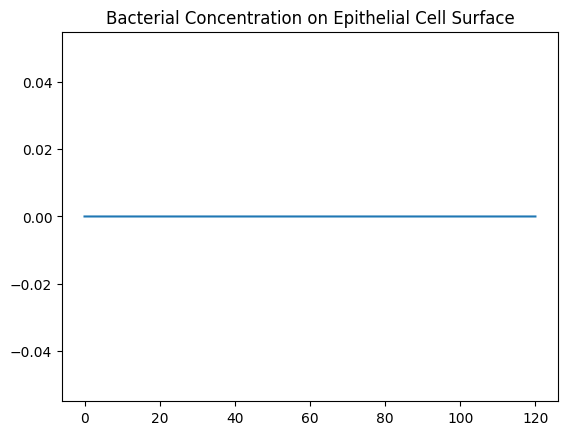

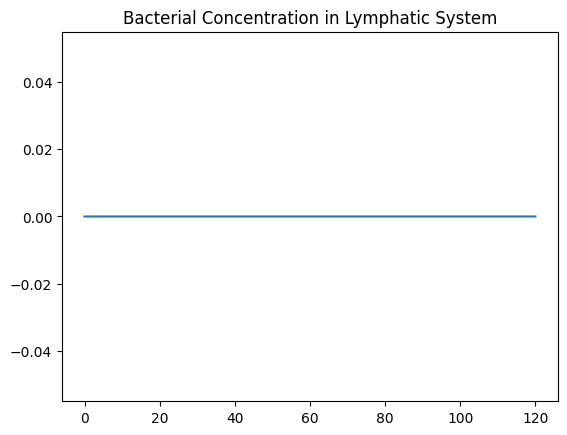

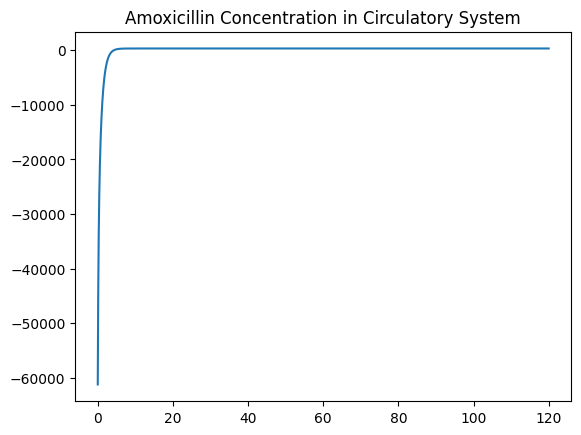

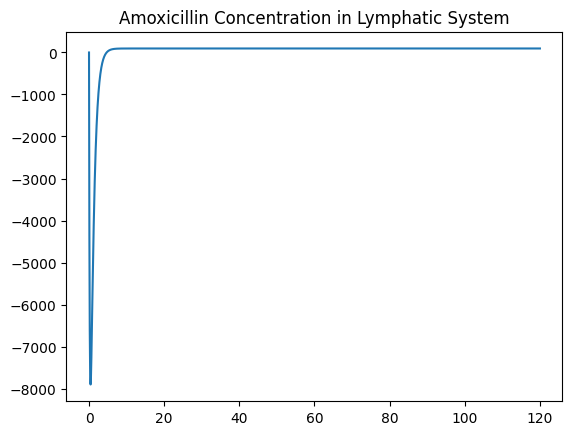

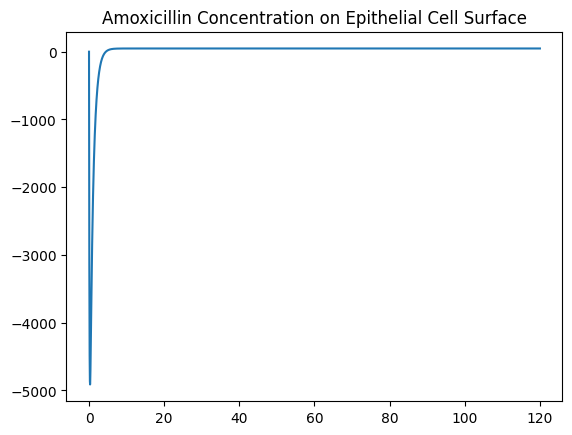

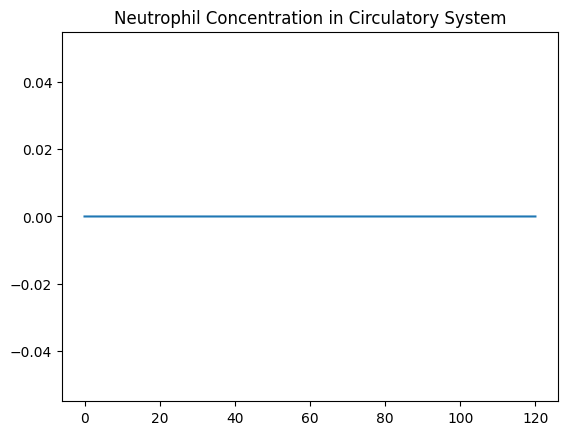

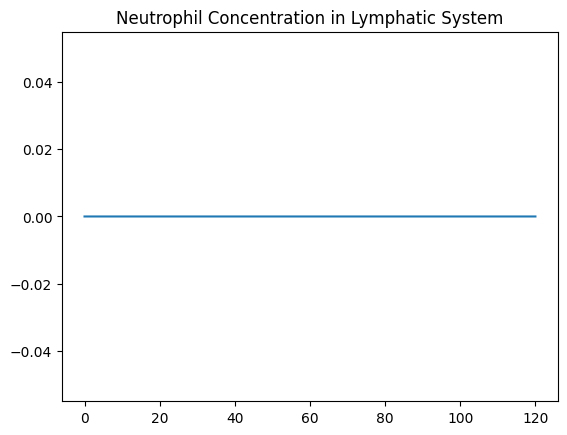

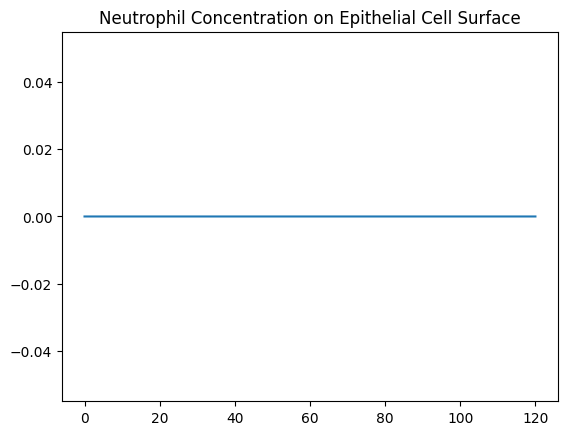

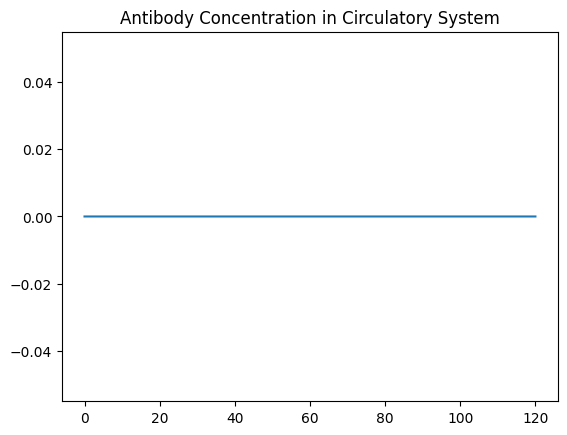

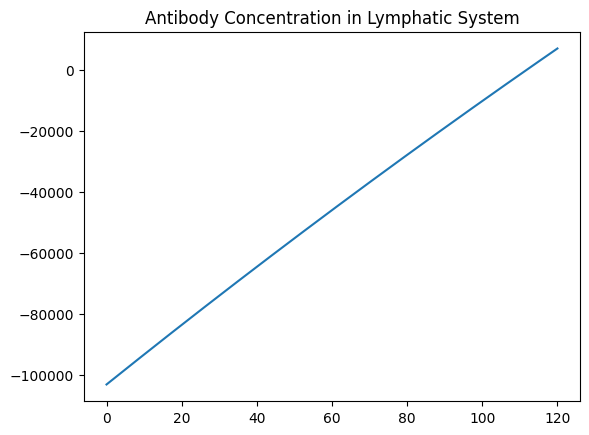

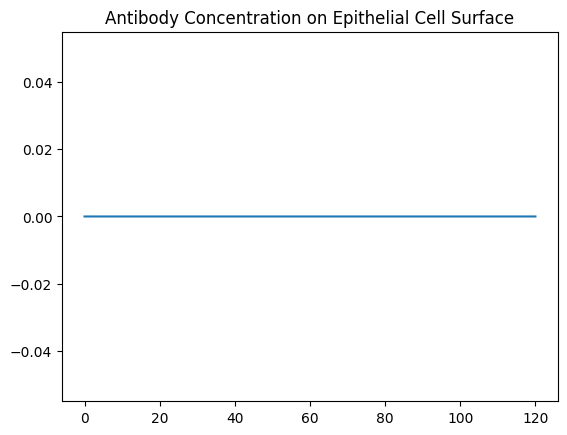

In [174]:
plt.plot(t, epiB, label='Bacterial Concentration on Epithelial Cell Surface')
plt.title('Bacterial Concentration on Epithelial Cell Surface')
plt.show()
plt.plot(t, lymB, label='Bacterial Concentration in Lymphatic System')
plt.title('Bacterial Concentration in Lymphatic System')
plt.show()
plt.plot(t, cirA, label='Amoxicillin Concentration in Circulatory System')
plt.title('Amoxicillin Concentration in Circulatory System')
plt.show()
plt.plot(t, lymA, label='Amoxicillin Concentration in Lymphatic System')
plt.title('Amoxicillin Concentration in Lymphatic System')
plt.show()
plt.plot(t, epiA, label='Amoxicillin Concentration on Epithelial Cell Surface')
plt.title('Amoxicillin Concentration on Epithelial Cell Surface')
plt.show()
plt.plot(t, cirN, label='Neutrophil Concentration in Circulatory System')
plt.title('Neutrophil Concentration in Circulatory System')
plt.show()
plt.plot(t, lymN, label='Neutrophil Concentration in Lymphatic System')
plt.title('Neutrophil Concentration in Lymphatic System')
plt.show()
plt.plot(t, epiN, label='Neutrophil Concentration on Epithelial Cell Surface')
plt.title('Neutrophil Concentration on Epithelial Cell Surface')
plt.show()
plt.plot(t, cirI, label='Antibody Concentration in Circulatory System')
plt.title('Antibody Concentration in Circulatory System')
plt.show()
plt.plot(t, lymI, label='Antibody Concentration in Lymphatic System')
plt.title('Antibody Concentration in Lymphatic System')
plt.show()
plt.plot(t, epiI, label='Antibody Concentration on Epithelial Cell Surface')
plt.title('Antibody Concentration on Epithelial Cell Surface')
plt.show()

plt.show()